In [1]:
import pandas as pd
import base64
from PIL import Image
from io import BytesIO


# Read the TSV file into a DataFrame
df = pd.read_csv('/home/ubuntu/Multimodal-Uncertainty-Quantification/datasets/MMT-Bench/MMT-Bench_VAL.tsv', sep='\t')

# # Access the values in each row using indexing or iteration
# print(df['Column 1'])
# print(df['Column 2'])

# # Process the values as needed
# print(df.head())  # Print the first few rows of the DataFrame

In [2]:
df.columns

Index(['index', 'question', 'answer', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H',
       'I', 'image', 'category', 'l2-category', 'split'],
      dtype='object')

In [3]:
len(df.category.value_counts())
# total 162 categories
print(df.category.unique())
# ['meme_vedio_understanding' 'meme_image_understanding'
#  'facail_expression_change_recognition' 'micro_expression_recognition'
#  'facial_expression_recognition' 'scene_emotion_recognition'
#  'artwork_emotion_recognition' 'body_emotion_recognition' 'whoops'
#  'reason_seg' 'referring_detection' 'ravens_progressive_matrices'
#  'image_matting' 'depth_estimation' 'pixel_localization'
#  'pixel_recognition' 'polygon_localization' 'interactive_segmentation'
#  'spot_the_similarity' 'spot_the_diff' 'image_colorization'
#  'jigsaw_puzzle_solving' 'counting_by_category'
#  'counting_by_visual_prompting' 'counting_by_reasoning' 'crowd_counting'
#  'doc_vqa' 'clock_reading' 'chart_to_text' 'chart_vqa'
#  'table_structure_recognition' 'visual_document_information_extraction'
#  'chart_to_table' 'one_shot_detection' 'single_object_tracking'
#  'point_tracking' 'animal_keypoint_detection' 'vehicle_keypoint_detection'
#  'clothes_keypoint_detection' 'human_keypoint_detection'
#  'furniture_keypoint_detection' 'navigation'
#  'multiple_view_image_understanding' 'temporal_sequence_understanding'
#  'traffic_light_understanding' 'traffic_sign_understanding'
#  'traffic_participants_understanding' 'human_interaction_understanding'
#  'human_object_interaction_recognition' 'social_relation_recognition'
#  'scene_graph_recognition' 'web_shopping' 'google_apps' 'gui_install'
#  'gui_general' 'vehicle_recognition' 'religious_recognition'
#  'plant_recognition' 'shape_recognition' 'gesture_recognition'
#  'chemical_apparatusn_recognition' 'rock_recognition'
#  'animated_character_recognition' 'profession_recognition'
#  'astronomical_recognition' 'sports_recognition' 'weapon_recognition'
#  'weather_recognition' 'landmark_recognition'
#  'texture_material_recognition' 'deepfake_detection' 'animals_recognition'
#  'muscial_instrument_recognition' 'fashion_recognition'
#  'color_recognition' 'food_recognition' 'film_and_television_recognition'
#  'national_flag_recognition' 'scene_recognition' 'celebrity_recognition'
#  'abstract_visual_recognition' 'sculpture_recognition'
#  'building_recognition' 'disaster_recognition' 'waste_recognition'
#  'image_season_recognition' 'logo_and_brand_recognition'
#  'electronic_object_recognition' 'painting_recognition'
#  'age_gender_race_recognition' 'image_quality_assessment'
#  'lvlm_response_judgement' 'face_detection'
#  'remote_sensing_object_detection' 'salient_object_detection_rgb'
#  'object_detection' 'camouflage_object_detection'
#  'transparent_object_detection' 'salient_object_detection_rgbd'
#  'small_object_detection' 'rotated_object_detection'
#  'visual_prompt_understanding' 'som_recognition' 'temporal_anticipation'
#  'temporal_ordering' 'next_img_prediction' 'mevis' 'temporal_localization'
#  'multiple_image_captioning' 'multiple_instance_captioning'
#  'image_dense_captioning' 'image_captioning' 'writing_poetry_from_image'
#  'image_captioning_paragraph' 'video_captioning' 'instance_captioning'
#  'health_medicine' 'science' 'tech_engineering' 'business'
#  'humanitites_social_science' 'art_design' 'color_assimilation'
#  'color_constancy' 'color_contrast' 'geometrical_relativity'
#  'geometrical_perspective' 'lesion_grading' 'disease_diagnose'
#  'anatomy_identification' 'medical_modality_recognition'
#  'other_biological_attributes' 'threed_cad_recognition'
#  'threed_indoor_recognition' 'text2image_retrieval' 'vehicle_retrieval'
#  'person_reid' 'image2image_retrieval' 'face_retrieval'
#  'sketch2image_retrieval' 'handwritten_retrieval'
#  'handwritten_text_recognition'
#  'handwritten_mathematical_expression_recognition'
#  'scene_text_recognition' 'font_recognition' 'order_hallucination'
#  'attribute_hallucination' 'exist_hallucination' 'relation_hallucination'
#  'gaze_estimation' 'sign_language_recognition'
#  'image_based_action_recognition' 'general_action_recognition'
#  'action_quality_assessment' 'eqn2latex' 'sketch2code' 'screenshot2code'
#  'traffic_anomaly_detection' 'industrial_produce_anomaly_detection'
#  'behavior_anomaly_detection' 'face_mask_anomaly_dectection'
#  'helmet_anomaly_detection']

# -------------
# categories related to health, med : health_medicine
# categories related to hallucination : 'order_hallucination', 'attribute_hallucination', 'exist_hallucination', 'relation_hallucination'

['meme_vedio_understanding' 'meme_image_understanding'
 'facail_expression_change_recognition' 'micro_expression_recognition'
 'facial_expression_recognition' 'scene_emotion_recognition'
 'artwork_emotion_recognition' 'body_emotion_recognition' 'whoops'
 'reason_seg' 'referring_detection' 'ravens_progressive_matrices'
 'image_matting' 'depth_estimation' 'pixel_localization'
 'pixel_recognition' 'polygon_localization' 'interactive_segmentation'
 'spot_the_similarity' 'spot_the_diff' 'image_colorization'
 'jigsaw_puzzle_solving' 'counting_by_category'
 'counting_by_visual_prompting' 'counting_by_reasoning' 'crowd_counting'
 'doc_vqa' 'clock_reading' 'chart_to_text' 'chart_vqa'
 'table_structure_recognition' 'visual_document_information_extraction'
 'chart_to_table' 'one_shot_detection' 'single_object_tracking'
 'point_tracking' 'animal_keypoint_detection' 'vehicle_keypoint_detection'
 'clothes_keypoint_detection' 'human_keypoint_detection'
 'furniture_keypoint_detection' 'navigation'
 'm

In [4]:
filtered_df_health = df[df['category'].str.startswith('health_medicine')]
filtered_df_health.shape
# only 14 samples

(14, 16)

In [5]:
filtered_df_hallucination = df[df['category'].str.contains('hallucination')]
filtered_df_hallucination.shape
# only 80 samples

(80, 16)

In [6]:
print(filtered_df_hallucination.index)

Index([2787, 2788, 2789, 2790, 2791, 2792, 2793, 2794, 2795, 2796, 2797, 2798,
       2799, 2800, 2801, 2802, 2803, 2804, 2805, 2806, 2807, 2808, 2809, 2810,
       2811, 2812, 2813, 2814, 2815, 2816, 2817, 2818, 2819, 2820, 2821, 2822,
       2823, 2824, 2825, 2826, 2827, 2828, 2829, 2830, 2831, 2832, 2833, 2834,
       2835, 2836, 2837, 2838, 2839, 2840, 2841, 2842, 2843, 2844, 2845, 2846,
       2847, 2848, 2849, 2850, 2851, 2852, 2853, 2854, 2855, 2856, 2857, 2858,
       2859, 2860, 2861, 2862, 2863, 2864, 2865, 2866],
      dtype='int64')


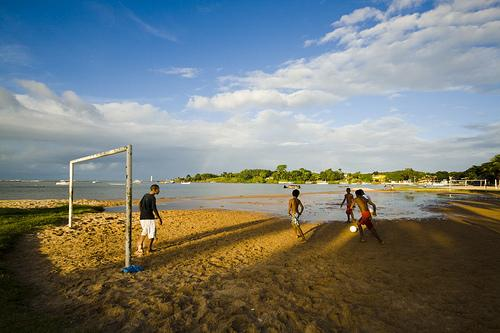

In [7]:

# Read the first row's image data
image_data_base64 = filtered_df_hallucination.loc[2787, 'image']

# Decode the base64 image
image_data = base64.b64decode(image_data_base64)

# Convert the binary data to an image
image = Image.open(BytesIO(image_data))

# Display the image
image.show()

#save
image.save('decoded_image.png')


In [8]:
filtered_df_hallucination.loc[2787,'question']

'Question: Based on the given image, which caption has the most correct ordering of the constituents?\n\nChoose the best answer from the following choices.'

In [9]:
filtered_df_hallucination.loc[2787:]

,index,question,answer,A,B,C,D,E,F,G,H,I,image,category,l2-category,split
2787,27925,"Question: Based on the given image, which capt...",B,Four people are playing soccer on a beach.,Four people are playing football by a body of ...,A group of people playing on a beach.,Some people are kicking a white ball on a beach.,NaN,NaN,NaN,NaN,NaN,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,order_hallucination,hallucination,VAL
2788,27926,"Question: Based on the given image, which capt...",A,"A group of people, mostly children, are playin...",A large display of a child's face over a water...,A group of girls are playing in a water founta...,Children play in a shallow pool next to a larg...,NaN,NaN,NaN,NaN,NaN,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,order_hallucination,hallucination,VAL
2789,27927,"Question: Based on the given image, which capt...",A,A small car decorated with flames and other pa...,A car with a bathtub on top participating in t...,"With a tub resting on its outer roof, flags at...",A Norfolk Race car with flames on the hood.,NaN,NaN,NaN,NaN,NaN,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,order_hallucination,hallucination,VAL
2790,27928,"Question: Based on the given image, which capt...",C,A man is standing by a group of video games in...,A man stands next to a bank of computer gambli...,A man standing in a bar with a neon beer sign ...,A man stands next to three video game machines...,NaN,NaN,NaN,NaN,NaN,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,order_hallucination,hallucination,VAL
2791,27929,"Question: Based on the given image, which capt...",A,A group of people are getting fountain drinks ...,Two guys getting a drink at a store counter.,Two boys in front of a soda machine.,Several adults are filling their cups and a dr...,NaN,NaN,NaN,NaN,NaN,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,order_hallucination,hallucination,VAL
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2862,28540,There are four images captions about the relat...,A,the sheep is to the right of the hose,the hose is to the right of the sheep,NaN,NaN,NaN,NaN,NaN,NaN,NaN,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,relation_hallucination,hallucination,VAL
2863,28541,There are four images captions about the relat...,A,the bear is crossing the road,the road is crossing the bear,NaN,NaN,NaN,NaN,NaN,NaN,NaN,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,relation_hallucination,hallucination,VAL
2864,28542,There are four images captions about the relat...,A,the cake is on the table,the table is on the cake,NaN,NaN,NaN,NaN,NaN,NaN,NaN,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,relation_hallucination,hallucination,VAL
2865,28543,There are four images captions about the relat...,B,the foil is on the lunch,the lunch is on the foil,NaN,NaN,NaN,NaN,NaN,NaN,NaN,/9j/4AAQSkZJRgABAQAAAQABAAD/2wBDAAgGBgcGBQgHBw...,relation_hallucination,hallucination,VAL


In [10]:
filtered_df_hallucination.loc[2787, 'B']

'Four people are playing football by a body of water in partly cloudy weather.'

In [11]:
filtered_df_hallucination.loc[2787, 'A']

'Four people are playing soccer on a beach.'

In [12]:
filtered_df_hallucination.loc[2787, 'C']


'A group of people playing on a beach.'

In [13]:
filtered_df_hallucination.loc[2787, 'D']


'Some people are kicking a white ball on a beach.'